In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('covid_19_data.csv.zip')

In [5]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  object 
 2   Province/State   228326 non-null  object 
 3   Country/Region   306429 non-null  object 
 4   Last Update      306429 non-null  object 
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 18.7+ MB


In [7]:
df.describe()

,SNo,Confirmed,Deaths,Recovered
count,306429.000000,3.064290e+05,306429.000000,3.064290e+05
mean,153215.000000,8.567091e+04,2036.403268,5.042029e+04
std,88458.577156,2.775516e+05,6410.938048,2.015124e+05
min,1.000000,-3.028440e+05,-178.000000,-8.544050e+05
25%,76608.000000,1.042000e+03,13.000000,1.100000e+01
50%,153215.000000,1.037500e+04,192.000000,1.751000e+03
75%,229822.000000,5.075200e+04,1322.000000,2.027000e+04
max,306429.000000,5.863138e+06,112385.000000,6.399531e+06


In [8]:
df.shape

(306429, 8)

In [9]:
# missing value cheak
df.isnull().sum()

SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64

In [10]:
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.rename(columns={'Country/Region': 'Country', 'Province/State': 'State'}, inplace=True)

In [13]:
df.head()

,SNo,ObservationDate,State,Country,Last Update,Confirmed,Deaths,Recovered
0,1,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [14]:
# sabse jyada death bale top 10 country
top_countries = df.groupby('Country')['Confirmed'].max().sort_values(ascending=False).head(15)
print(top_countries)

Country
France            5863138.0
India             5713215.0
Turkey            5235978.0
UK                3910803.0
US                3788713.0
Argentina         3732263.0
Brazil            3254893.0
Iran              2893218.0
Poland            2871371.0
Indonesia         1809926.0
Czech Republic    1660935.0
South Africa      1659070.0
Philippines       1216582.0
Iraq              1193608.0
Russia            1173637.0
Name: Confirmed, dtype: float64


In [15]:
print("Total Conformed : ",df['Confirmed'].sum())
print('Total Deaths : ',df['Deaths'].sum())
print('Total Recovered : ',df['Recovered'].sum())

Total Conformed :  26252051758.0
Total Deaths :  624013017.0
Total Recovered :  15450237912.0


In [16]:
indian_deaths = df[df['Country'] == 'India']['Deaths'].sum()
print('Total Death in India : ',indian_deaths)

Total Death in India :  44424723.0


In [17]:
indian_confirmed = df[df['Country'] == 'India']['Confirmed'].sum()
print('Total Confirmed in India : ',indian_confirmed)

Total Confirmed in India :  3226768088.0


In [18]:
print(df.columns)

latest_date = df['ObservationDate'].max()
latest_df = df[df['ObservationDate'] == latest_date]

print('Total Confirmed in India : ',latest_df[latest_df['Country'] == 'India']['Confirmed'].sum())

Index(['SNo', 'ObservationDate', 'State', 'Country', 'Last Update',
       'Confirmed', 'Deaths', 'Recovered'],
      dtype='object')
Total Confirmed in India :  27894800.0


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# top 10 country bar chart

C:\Users\hp\AppData\Local\Temp\ipykernel_9036\2252392802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


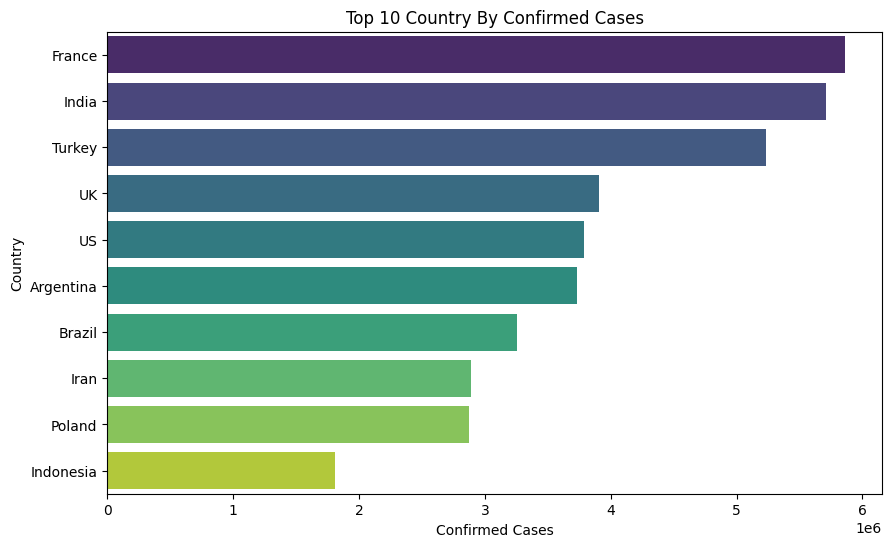

In [20]:
top10 = df.groupby('Country')['Confirmed'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Country By Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.show()

# india ka trend over time -Line Chart

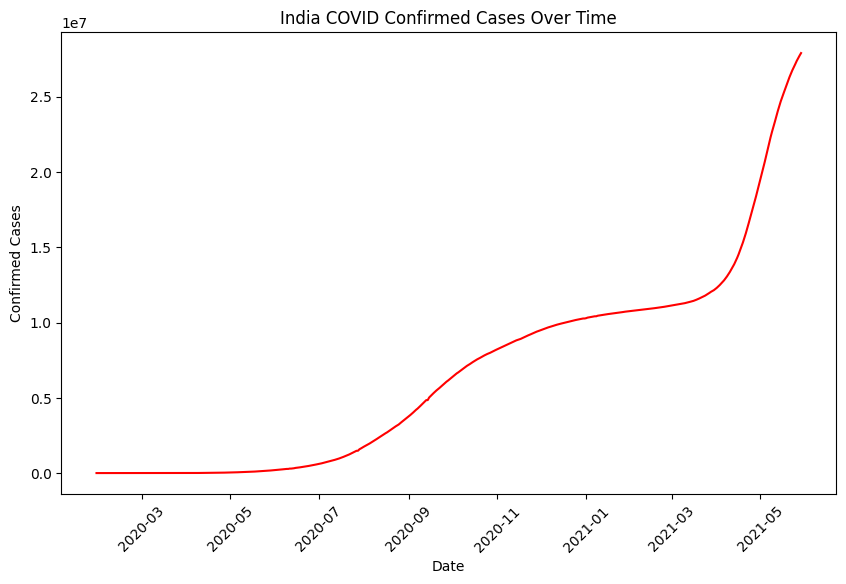

In [21]:
# observationDate ----> datetime formet
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

india_data = df[df['Country'] == 'India']
india_trend = india_data.groupby('ObservationDate')['Confirmed'].sum()

plt.figure(figsize=(10,6))
plt.plot(india_trend.index, india_trend.values, color='red')
plt.title('India COVID Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.show()

# death vs recovered -- comparision

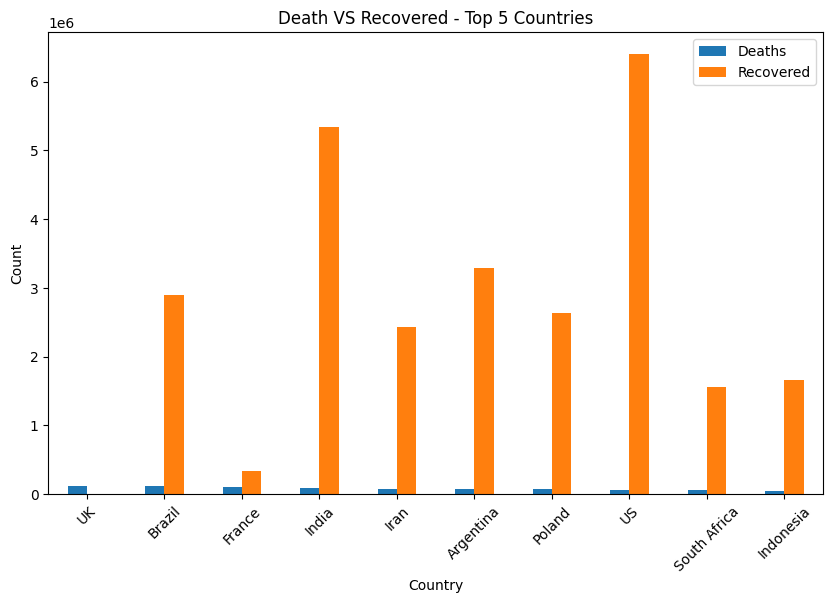

In [22]:
top5 = df.groupby('Country')[['Deaths','Recovered']].max().sort_values('Deaths', ascending=False).head(10)

top5.plot(kind='bar', figsize=(10,6))
plt.title('Death VS Recovered - Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# death vs recovered -- comparision in INDIA

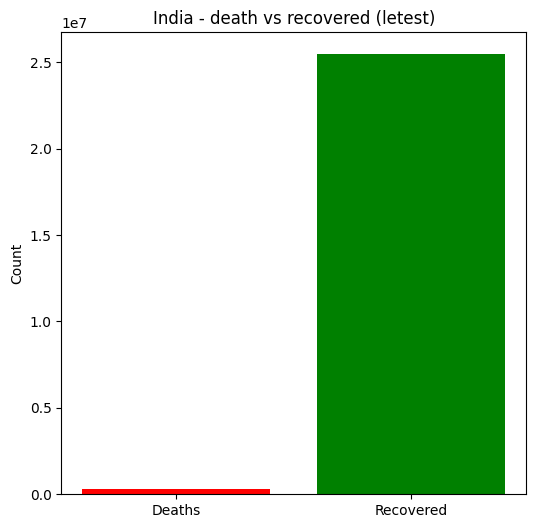

In [23]:
india_data = df[df['Country'] == 'India']
latest_india = india_data[india_data['ObservationDate'] == india_data['ObservationDate'].max()]

deaths = latest_india['Deaths'].sum()
recovered = latest_india['Recovered'].sum()

plt.figure(figsize=(6,6))
plt.bar(['Deaths', 'Recovered'], [deaths, recovered], color=['red', 'green'])
plt.title('India - death vs recovered (letest)')
plt.ylabel('Count')
plt.show()

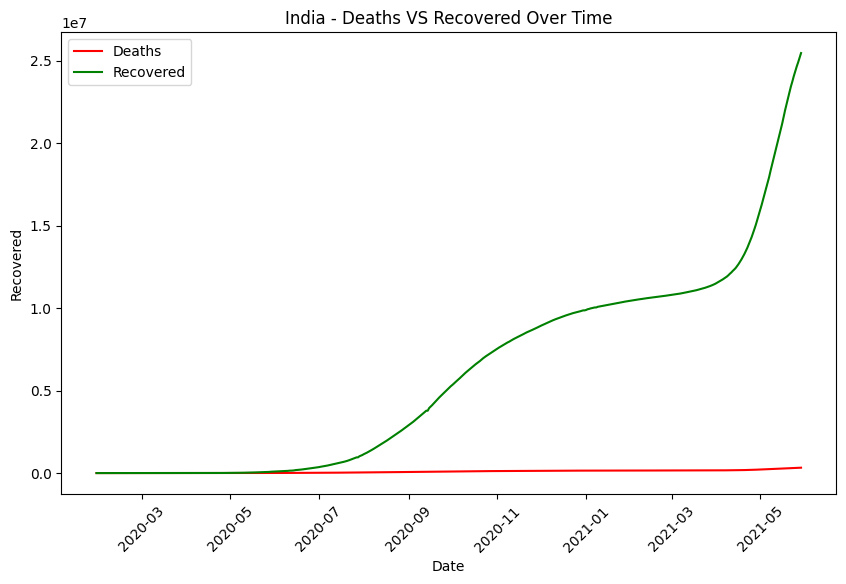

In [24]:
india_trend = india_data.groupby('ObservationDate')[['Deaths','Recovered']].sum().sort_index()

plt.figure(figsize=(10,6))
plt.plot(india_trend.index, india_trend['Deaths'], color='red', label='Deaths')
plt.plot(india_trend.index, india_trend['Recovered'], color='green', label='Recovered')
plt.title('India - Deaths VS Recovered Over Time')
plt.xlabel('Date')
plt.ylabel('Recovered')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# recovery rate our death rate india ke liye 

In [25]:
latest_india = india_data[india_data['ObservationDate'] == india_data['ObservationDate'].max()]

confirmed = latest_india['Confirmed'].sum()
deaths = latest_india['Deaths'].sum()
recovered = latest_india['Recovered'].sum()

death_rate = (deaths / confirmed) * 100
recovered_rate = (recovered / confirmed) * 100

print(f"Death Rate : {death_rate:.2f}%")
print(f"Recovered Rate : {recovered_rate:.2f}%")

Death Rate : 1.17%
Recovered Rate : 91.25%


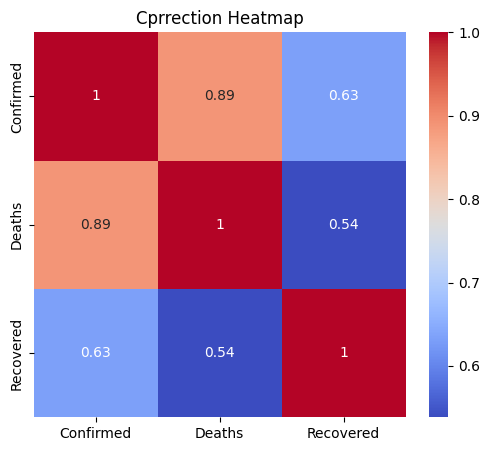

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Confirmed','Deaths','Recovered']].corr(), annot=True, cmap='coolwarm')
plt.title('Cprrection Heatmap')
plt.show()

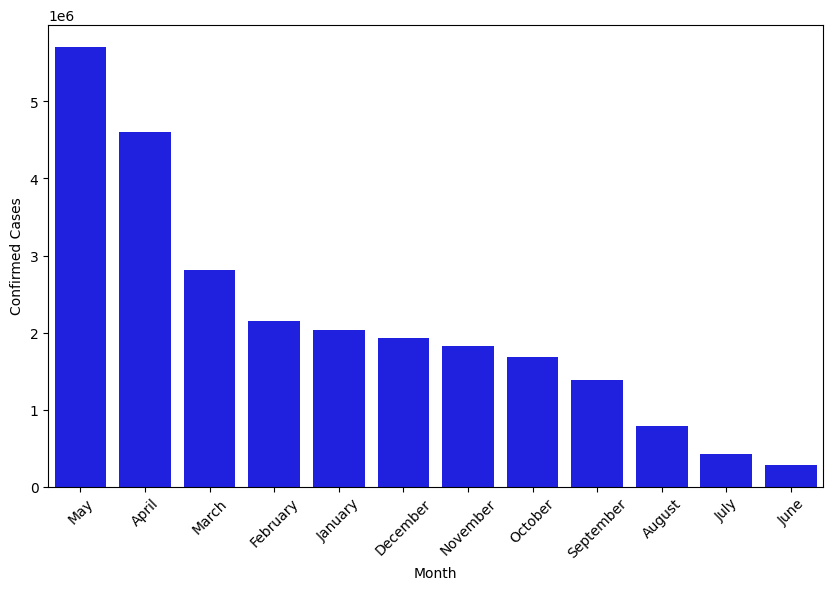

In [28]:
india_data = india_data.copy()
india_data['Month'] = india_data['ObservationDate'].dt.month_name()
monthly = india_data.groupby('Month')['Confirmed'].max().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=monthly.index, y=monthly.values, color='blue')
plt.xlabel('Month')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.show()